In [1]:
# ============================================
# CUSTOMER CHURN PREDICTION - COLAB PROJECT
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ============================================
# GENERATE SYNTHETIC CUSTOMER DATA
# ============================================

N = 5000

customer_id = [
    f"CUST{str(i).zfill(5)}"
    for i in range(1, N + 1)
]

gender = np.random.choice(
    ["Male", "Female"],
    size=N
)

age = np.random.randint(
    18, 76,
    size=N
)

senior_citizen = np.where(
    age >= 60, 1, 0
)

partner = np.random.choice(
    ["Yes", "No"],
    size=N,
    p=[0.48, 0.52]
)

dependents = np.random.choice(
    ["Yes", "No"],
    size=N,
    p=[0.30, 0.70]
)

# Tenure in months
tenure_months = np.random.randint(
    1, 73,
    size=N
)

phone_service = np.random.choice(
    ["Yes", "No"],
    size=N,
    p=[0.90, 0.10]
)

internet_service = np.random.choice(
    ["Fiber optic", "DSL", "No"],
    size=N,
    p=[0.45, 0.40, 0.15]
)

contract = np.random.choice(
    ["Month-to-month", "One year", "Two year"],
    size=N,
    p=[0.55, 0.25, 0.20]
)

payment_method = np.random.choice(
    [
        "Electronic check",
        "Credit card",
        "Bank transfer",
        "Mailed check"
    ],
    size=N,
    p=[0.35, 0.30, 0.20, 0.15]
)

# Monthly charges based partly on internet service
monthly_charges = []

for service in internet_service:

    if service == "Fiber optic":
        charge = np.random.normal(85, 15)

    elif service == "DSL":
        charge = np.random.normal(60, 12)

    else:
        charge = np.random.normal(25, 8)

    monthly_charges.append(charge)

monthly_charges = np.clip(
    monthly_charges,
    18,
    150
)

monthly_charges = np.round(
    monthly_charges,
    2
)

# Total charges
total_charges = (
    monthly_charges * tenure_months
    + np.random.normal(0, 100, N)
)

total_charges = np.maximum(
    total_charges,
    0
)

total_charges = np.round(
    total_charges,
    2
)

# Support tickets
support_tickets = np.random.poisson(
    lam=2.5,
    size=N
)

support_tickets = np.clip(
    support_tickets,
    0,
    15
)

# Late payments
late_payments = np.random.poisson(
    lam=1.2,
    size=N
)

late_payments = np.clip(
    late_payments,
    0,
    10
)

# Data usage
data_usage_gb = np.random.gamma(
    shape=4,
    scale=10,
    size=N
)

data_usage_gb = np.clip(
    data_usage_gb,
    1,
    150
)

data_usage_gb = np.round(
    data_usage_gb,
    2
)

# Number of services
num_services = np.random.randint(
    1,
    7,
    size=N
)

# ============================================
# CHURN GENERATION
# ============================================

# Start with baseline log-odds
churn_score = np.full(N, -1.5)

# Month-to-month contracts increase churn
churn_score += np.where(
    contract == "Month-to-month",
    1.2,
    0
)

churn_score += np.where(
    contract == "One year",
    -0.3,
    0
)

churn_score += np.where(
    contract == "Two year",
    -0.9,
    0
)

# Short tenure increases churn
churn_score += np.where(
    tenure_months <= 12,
    0.9,
    0
)

churn_score += np.where(
    tenure_months >= 48,
    -0.6,
    0
)

# High monthly charges
churn_score += np.where(
    monthly_charges > 80,
    0.5,
    0
)

# Support problems
churn_score += (
    support_tickets * 0.10
)

# Late payments
churn_score += (
    late_payments * 0.15
)

# Fiber customers slightly higher churn
churn_score += np.where(
    internet_service == "Fiber optic",
    0.25,
    0
)

# Electronic check
churn_score += np.where(
    payment_method == "Electronic check",
    0.35,
    0
)

# Senior citizens
churn_score += np.where(
    senior_citizen == 1,
    0.25,
    0
)

# Partner reduces churn
churn_score += np.where(
    partner == "Yes",
    -0.2,
    0
)

# Dependents reduce churn
churn_score += np.where(
    dependents == "Yes",
    -0.15,
    0
)

# More services reduce churn
churn_score += np.where(
    num_services >= 5,
    -0.3,
    0
)

# Convert score to probability
churn_probability = (
    1 / (1 + np.exp(-churn_score))
)

# Add randomness
churn = np.random.binomial(
    1,
    churn_probability
)

churn_label = np.where(
    churn == 1,
    "Yes",
    "No"
)

# ============================================
# CREATE DATAFRAME
# ============================================

df = pd.DataFrame({
    "customerID": customer_id,
    "gender": gender,
    "age": age,
    "seniorCitizen": senior_citizen,
    "partner": partner,
    "dependents": dependents,
    "tenureMonths": tenure_months,
    "phoneService": phone_service,
    "internetService": internet_service,
    "contract": contract,
    "paymentMethod": payment_method,
    "monthlyCharges": monthly_charges,
    "totalCharges": total_charges,
    "supportTickets": support_tickets,
    "latePayments": late_payments,
    "dataUsageGB": data_usage_gb,
    "numServices": num_services,
    "churn": churn_label
})

print("Dataset generated successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset generated successfully!
Rows: 5000
Columns: 18


,customerID,gender,age,seniorCitizen,partner,dependents,tenureMonths,phoneService,internetService,contract,paymentMethod,monthlyCharges,totalCharges,supportTickets,latePayments,dataUsageGB,numServices,churn
0,CUST00001,Male,68,1,Yes,No,5,No,Fiber optic,One year,Electronic check,87.91,606.65,1,1,53.98,5,No
1,CUST00002,Female,64,1,Yes,No,62,Yes,Fiber optic,One year,Bank transfer,88.82,5347.19,3,1,42.99,2,No
2,CUST00003,Male,64,1,Yes,No,5,Yes,Fiber optic,Month-to-month,Electronic check,58.63,158.43,4,1,43.77,3,No
3,CUST00004,Male,21,0,No,No,10,Yes,DSL,One year,Electronic check,59.07,638.82,2,1,39.36,2,No
4,CUST00005,Male,24,0,Yes,Yes,63,Yes,No,Two year,Electronic check,25.05,1471.32,1,1,35.69,4,No


In [3]:
# Dataset information

print("Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nChurn Distribution:")
print(df["churn"].value_counts())

print("\nChurn Percentage:")
print(
    df["churn"].value_counts(normalize=True) * 100
)

Shape:
(5000, 18)

Data Types:
customerID          object
gender              object
age                  int64
seniorCitizen        int64
partner             object
dependents          object
tenureMonths         int64
phoneService        object
internetService     object
contract            object
paymentMethod       object
monthlyCharges     float64
totalCharges       float64
supportTickets       int64
latePayments         int64
dataUsageGB        float64
numServices          int64
churn               object
dtype: object

Missing Values:
customerID         0
gender             0
age                0
seniorCitizen      0
partner            0
dependents         0
tenureMonths       0
phoneService       0
internetService    0
contract           0
paymentMethod      0
monthlyCharges     0
totalCharges       0
supportTickets     0
latePayments       0
dataUsageGB        0
numServices        0
churn              0
dtype: int64

Duplicate Rows:
0

Churn Distribution:
churn
No     2942
Yes

In [4]:
# Save raw dataset

df.to_csv(
    "customer_churn_dataset.csv",
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!


In [5]:
from google.colab import files

files.download(
    "customer_churn_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# ============================================
# DATA CLEANING
# ============================================

data = df.copy()

# Remove duplicates
data = data.drop_duplicates()

# Convert total charges to numeric
data["totalCharges"] = pd.to_numeric(
    data["totalCharges"],
    errors="coerce"
)

# Fill missing numerical values
data["totalCharges"] = data["totalCharges"].fillna(
    data["totalCharges"].median()
)

# Remove impossible ages
data = data[
    (data["age"] >= 18) &
    (data["age"] <= 100)
]

# Remove impossible monthly charges
data = data[
    data["monthlyCharges"] > 0
]

print("After cleaning:")
print(data.shape)

print("\nMissing values:")
print(data.isnull().sum())

After cleaning:
(5000, 18)

Missing values:
customerID         0
gender             0
age                0
seniorCitizen      0
partner            0
dependents         0
tenureMonths       0
phoneService       0
internetService    0
contract           0
paymentMethod      0
monthlyCharges     0
totalCharges       0
supportTickets     0
latePayments       0
dataUsageGB        0
numServices        0
churn              0
dtype: int64


In [7]:
# ============================================
# FEATURE ENGINEERING
# ============================================

data["avgMonthlySpend"] = (
    data["totalCharges"] /
    data["tenureMonths"].replace(0, 1)
)

data["supportTicketRate"] = (
    data["supportTickets"] /
    data["tenureMonths"].replace(0, 1)
)

data["latePaymentRate"] = (
    data["latePayments"] /
    data["tenureMonths"].replace(0, 1)
)

data["isHighValueCustomer"] = np.where(
    data["monthlyCharges"] >= 80,
    1,
    0
)

data["isNewCustomer"] = np.where(
    data["tenureMonths"] <= 6,
    1,
    0
)

data["isLongTermCustomer"] = np.where(
    data["tenureMonths"] >= 36,
    1,
    0
)

print(
    data[
        [
            "avgMonthlySpend",
            "supportTicketRate",
            "latePaymentRate",
            "isHighValueCustomer",
            "isNewCustomer",
            "isLongTermCustomer"
        ]
    ].head()
)

   avgMonthlySpend  supportTicketRate  latePaymentRate  isHighValueCustomer  \
0       121.330000           0.200000         0.200000                    1   
1        86.245000           0.048387         0.016129                    1   
2        31.686000           0.800000         0.200000                    0   
3        63.882000           0.200000         0.100000                    0   
4        23.354286           0.015873         0.015873                    0   

   isNewCustomer  isLongTermCustomer  
0              1                   0  
1              0                   1  
2              1                   0  
3              0                   0  
4              0                   1  


In [8]:
# ============================================
# FEATURES & TARGET
# ============================================

X = data.drop(
    columns=["churn", "customerID"]
)

y = data["churn"].map({
    "Yes": 1,
    "No": 0
})

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features: (5000, 22)
Target: (5000,)

Target distribution:
churn
0    2942
1    2058
Name: count, dtype: int64


In [9]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'seniorCitizen', 'tenureMonths', 'monthlyCharges', 'totalCharges', 'supportTickets', 'latePayments', 'dataUsageGB', 'numServices', 'avgMonthlySpend', 'supportTicketRate', 'latePaymentRate', 'isHighValueCustomer', 'isNewCustomer', 'isLongTermCustomer']

Categorical Features:
['gender', 'partner', 'dependents', 'phoneService', 'internetService', 'contract', 'paymentMethod']


In [10]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [11]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [12]:
# ============================================
# MACHINE LEARNING MODEL
# ============================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

Model training completed!


In [13]:
# ============================================
# PREDICTION
# ============================================

y_pred = model.predict(X_test)

y_probability = model.predict_proba(
    X_test
)[:, 1]

print("Predictions:")
print(y_pred[:10])

print("\nChurn probabilities:")
print(y_probability[:10])

Predictions:
[0 1 1 0 0 1 1 0 0 1]

Churn probabilities:
[0.11138983 0.68554018 0.51147009 0.3873302  0.09007154 0.60653964
 0.70917313 0.25439173 0.36742324 0.55385711]


In [14]:
# ============================================
# MODEL EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("================================")
print("MODEL PERFORMANCE")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

MODEL PERFORMANCE
Accuracy  : 0.6980
Precision : 0.6361
Recall    : 0.6238
F1 Score  : 0.6299
ROC-AUC   : 0.7662


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.74      0.75      0.74       588
       Churn       0.64      0.62      0.63       412

    accuracy                           0.70      1000
   macro avg       0.69      0.69      0.69      1000
weighted avg       0.70      0.70      0.70      1000



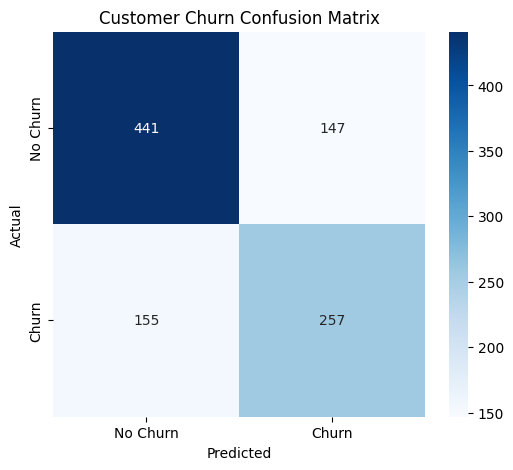

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Churn Confusion Matrix")

plt.show()

In [17]:
# ============================================
# TEST NEW CUSTOMER
# ============================================

new_customer = pd.DataFrame([{
    "gender": "Male",
    "age": 35,
    "seniorCitizen": 0,
    "partner": "No",
    "dependents": "No",
    "tenureMonths": 8,
    "phoneService": "Yes",
    "internetService": "Fiber optic",
    "contract": "Month-to-month",
    "paymentMethod": "Electronic check",
    "monthlyCharges": 92.50,
    "totalCharges": 740.00,
    "supportTickets": 5,
    "latePayments": 3,
    "dataUsageGB": 85.5,
    "numServices": 3
}])

# Feature engineering for API input

new_customer["avgMonthlySpend"] = (
    new_customer["totalCharges"] /
    new_customer["tenureMonths"].replace(0, 1)
)

new_customer["supportTicketRate"] = (
    new_customer["supportTickets"] /
    new_customer["tenureMonths"].replace(0, 1)
)

new_customer["latePaymentRate"] = (
    new_customer["latePayments"] /
    new_customer["tenureMonths"].replace(0, 1)
)

new_customer["isHighValueCustomer"] = np.where(
    new_customer["monthlyCharges"] >= 80,
    1,
    0
)

new_customer["isNewCustomer"] = np.where(
    new_customer["tenureMonths"] <= 6,
    1,
    0
)

new_customer["isLongTermCustomer"] = np.where(
    new_customer["tenureMonths"] >= 36,
    1,
    0
)

# Prediction
prediction = model.predict(
    new_customer
)[0]

probability = model.predict_proba(
    new_customer
)[0][1]

print("================================")
print("CUSTOMER CHURN PREDICTION")
print("================================")

print(
    "Prediction:",
    "Churn" if prediction == 1 else "No Churn"
)

print(
    f"Churn Probability: {probability * 100:.2f}%"
)

print(
    f"Confidence Score: {max(probability, 1-probability) * 100:.2f}%"
)

CUSTOMER CHURN PREDICTION
Prediction: Churn
Churn Probability: 90.81%
Confidence Score: 90.81%


In [18]:
# ============================================
# API STYLE RESPONSE
# ============================================

prediction_label = (
    "Churn"
    if prediction == 1
    else "No Churn"
)

response = {
    "success": True,
    "prediction": prediction_label,
    "churnProbability": round(
        float(probability),
        4
    ),
    "confidenceScore": round(
        float(max(probability, 1 - probability)),
        4
    )
}

response

{'success': True,
 'prediction': 'Churn',
 'churnProbability': 0.9081,
 'confidenceScore': 0.9081}

In [19]:
# ============================================
# SAVE TRAINED MODEL
# ============================================

joblib.dump(
    model,
    "churn_model.pkl"
)

print(
    "Model saved as churn_model.pkl"
)

Model saved as churn_model.pkl


In [20]:
from google.colab import files

files.download(
    "churn_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ============================================
# LOAD SAVED MODEL
# ============================================

loaded_model = joblib.load(
    "churn_model.pkl"
)

test_prediction = loaded_model.predict(
    new_customer
)[0]

test_probability = loaded_model.predict_proba(
    new_customer
)[0][1]

print(
    "Prediction:",
    "Churn" if test_prediction == 1 else "No Churn"
)

print(
    f"Probability: {test_probability:.4f}"
)

Prediction: Churn
Probability: 0.9081


In [22]:
# ============================================
# CREATE A DIRTY DATA SAMPLE
# ============================================

dirty_df = df.copy()

# Add some missing values
dirty_df.loc[10:20, "totalCharges"] = np.nan
dirty_df.loc[30:35, "monthlyCharges"] = np.nan

# Add duplicate rows
dirty_df = pd.concat(
    [dirty_df, dirty_df.iloc[:10]],
    ignore_index=True
)

print("Before cleaning:")
print("Rows:", len(dirty_df))
print(
    "Missing values:",
    dirty_df.isnull().sum().sum()
)
print(
    "Duplicates:",
    dirty_df.duplicated().sum()
)

Before cleaning:
Rows: 5010
Missing values: 17
Duplicates: 10


In [25]:
%cd /content

/content


In [26]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_dataset.csv to customer_churn_dataset (1).csv


In [27]:
!ls -lh *.csv *.pkl

-rw-r--r-- 1 root root 7.0K Oct  2 07:26  churn_model.pkl
-rw-r--r-- 1 root root 477K Oct  2 07:44 'customer_churn_dataset (1).csv'
-rw-r--r-- 1 root root 477K Oct  2 07:24  customer_churn_dataset.csv
